In [20]:
import torch
 
print(f"PyTorch version {torch.__version__}")
if torch.cuda.is_available():
    print("CUDA GPU")
elif torch.xpu.is_available():
    print("Intel GPU")
elif torch.mps.is_available():
    print("Apple Silicon GPU")
 
else:
    print("Only CPU")

PyTorch version 2.11.0
Apple Silicon GPU


In [ ]:
from pathlib import Path
from reasoning_from_scratch.qwen3 import download_qwen3_small
from reasoning_from_scratch.qwen3 import Qwen3Tokenizer


# Define the output directory and ensure it exists
out_dir = Path("../../_models/qwen3").resolve()
out_dir.mkdir(parents=True, exist_ok=True)

download_qwen3_small(kind="base", tokenizer_only=False, out_dir=str(out_dir))
#download_qwen3_small(kind="base", tokenizer_only=True, out_dir=str(out_dir))

tokenizer_path = Path(str(out_dir)) / "tokenizer-base.json"
tokenizer = Qwen3Tokenizer(tokenizer_file_path=tokenizer_path)

qwen3-0.6B-base.pth: 100% (1433 MiB / 1433 MiB)


In [17]:
# 2.4 Preparing Input for Text Generations
# We will do Tokenization Round Trip. i.e. encode a text into token IDs and decode those IDs back to Text
prompt = "Explain large language models."

input_token_ids_list = tokenizer.encode(prompt) # outputs a list. 
print(input_token_ids_list)

text = tokenizer.decode(input_token_ids_list)
print(text)
print("\n")

for i in input_token_ids_list:
    print(f"{[i]} --> {tokenizer.decode([i])}")

[840, 20772, 3460, 4128, 4119, 13]
Explain large language models.


[840] --> Ex
[20772] --> plain
[3460] -->  large
[4128] -->  language
[4119] -->  models
[13] --> .


"Explain" was split into two separate tokens, "Ex" and "plain". -> subword-based method based on Byte Pair Encoding (BPE). 

BPE can represent both common and rare words using a mix of full words and subword units. spaces are also often included in tokens (for example, " large"), which helps the LLM detect word boundaries.

The Qwen3Tokenizer - Vocab Size - 151,000 tokens. A larger vocabulary - more represented, but increase in computational cost.  Splitting a word (like breaking "Explain" into "Ex" and "plain") results in more input tokens. More tokens lead to longer input sequences, which increases processing time and resource usage. 


In [ ]:
# Note that if you have a modern NVIDIA GPU (based on the Ampere architecture or newer), the get_device() function automatically enables Tensor Cores for faster matrix multiplications when enable_tensor_cores=True.

def get_device(enable_tensor_cores=True):
    if torch.cuda.is_available():
        device = torch.device("cuda")
        print("Using NVIDIA CUDA GPU")
        
        if enable_tensor_cores:
            major, minor = map(int, torch.__version__.split(".")[:2])
            if (major, minor) >= (2, 9):
                torch.backends.cuda.matmul.fp32_precision = "tf32"
                torch.backends.cudnn.conv.fp32_precision = "tf32"
            else:
                torch.backends.cuda.matmul.allow_tf32 = True
                torch.backends.cudnn.allow_tf32 = True
 
    elif torch.backends.mps.is_available():
        device = torch.device("mps")
        print("Using Apple Silicon GPU (MPS)")
 
    elif torch.xpu.is_available():
        device = torch.device("xpu")
        print("Using Intel GPU")
 
    else:
        device = torch.device("cpu")
        print("Using CPU")
 
    return device

In [21]:
from reasoning_from_scratch.qwen3 import Qwen3Model, QWEN_CONFIG_06_B
 
model_path = Path(str(out_dir)) / "qwen3-0.6B-base.pth"
model = Qwen3Model(QWEN_CONFIG_06_B)

# torch.load -> reload the checkpoint file from disk
# returns a dictionary of tensors containing saved weights / parameters
# model.load_state_dict -> takes that dict & restores all layer weights
# model is initialized with trained params

model.load_state_dict(torch.load(model_path))
model.to(get_device()) # Move weights to CUDA / MPS / CPU

Using Apple Silicon GPU (MPS)


Qwen3Model(
  (tok_emb): Embedding(151936, 1024)
  (trf_blocks): ModuleList(
    (0-27): 28 x TransformerBlock(
      (att): GroupedQueryAttention(
        (W_query): Linear(in_features=1024, out_features=2048, bias=False)
        (W_key): Linear(in_features=1024, out_features=1024, bias=False)
        (W_value): Linear(in_features=1024, out_features=1024, bias=False)
        (out_proj): Linear(in_features=2048, out_features=1024, bias=False)
        (q_norm): RMSNorm()
        (k_norm): RMSNorm()
      )
      (ff): FeedForward(
        (fc1): Linear(in_features=1024, out_features=3072, bias=False)
        (fc2): Linear(in_features=1024, out_features=3072, bias=False)
        (fc3): Linear(in_features=3072, out_features=1024, bias=False)
      )
      (norm1): RMSNorm()
      (norm2): RMSNorm()
    )
  )
  (final_norm): RMSNorm()
  (out_head): Linear(in_features=1024, out_features=151936, bias=False)
)

Input text is tokenized and passed through an embedding layer, followed by 28 repeated transformer blocks. Each block contains _grouped-query attention, feedforward layers, and RMS normalization_. The model ends with a final normalization and linear output layer. 


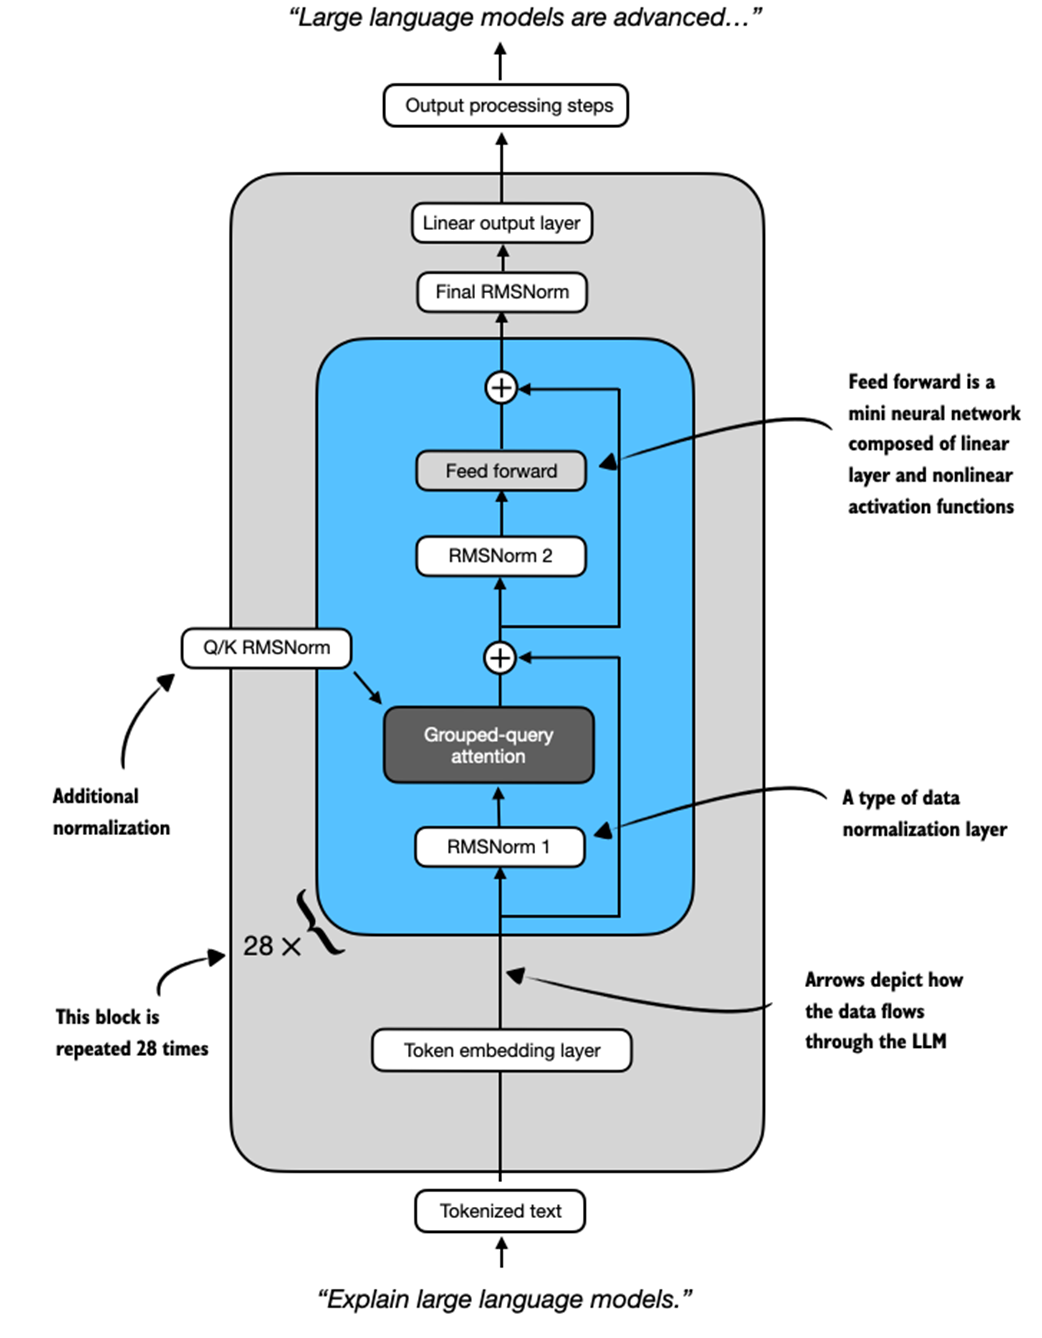

Text generation in LLMs is a sequential process where LLMs generate one word at a time. This is often also called autoregressive text generation

The LLM generates an output sequence that mirrors the input but is shifted one position to the right. At each iteration, the model predicts the next token in the sequence, The LLM effectively learns to continue the input prompt one token at a time.

The .squeeze() and .unsqueeze() operations in PyTorch are used to change the shape of a tensor by removing or adding dimensions of size 1. This is often useful for reshaping a tensor to match what a model expects.


In [32]:
prompt = "Explain large language models."
input_token_ids_list = tokenizer.encode(prompt)
print(f"Number of input tokens: {len(input_token_ids_list)}")

input_tensor = torch.tensor(input_token_ids_list)
input_tensor_fmt = input_tensor.unsqueeze(0)
input_tensor_fmt = input_tensor_fmt.to(get_device())

output_tensor = model(input_tensor_fmt)
print(output_tensor.shape)
output_tensor_fmt = output_tensor.squeeze(0)
print(f"Formatted Output tensor shape: {output_tensor_fmt.shape}")

Number of input tokens: 6
Using Apple Silicon GPU (MPS)
torch.Size([1, 6, 151936])
Formatted Output tensor shape: torch.Size([6, 151936])


we feed six input tokens into the model, which returns a 6×151,936-dimensional matrix. The 6 in this matrix corresponds to the six input tokens. The second dimension, 151,936, corresponds to the vocabulary size that the model supports. For instance, each of the six tokens is represented by a vector with 151,936 values.

So, to get the next generated word, we extract the last row of this 6×151,936-dimensional matrix, find the token ID corresponding to the largest score value in this row, and convert this token ID back into text via the tokenizer,

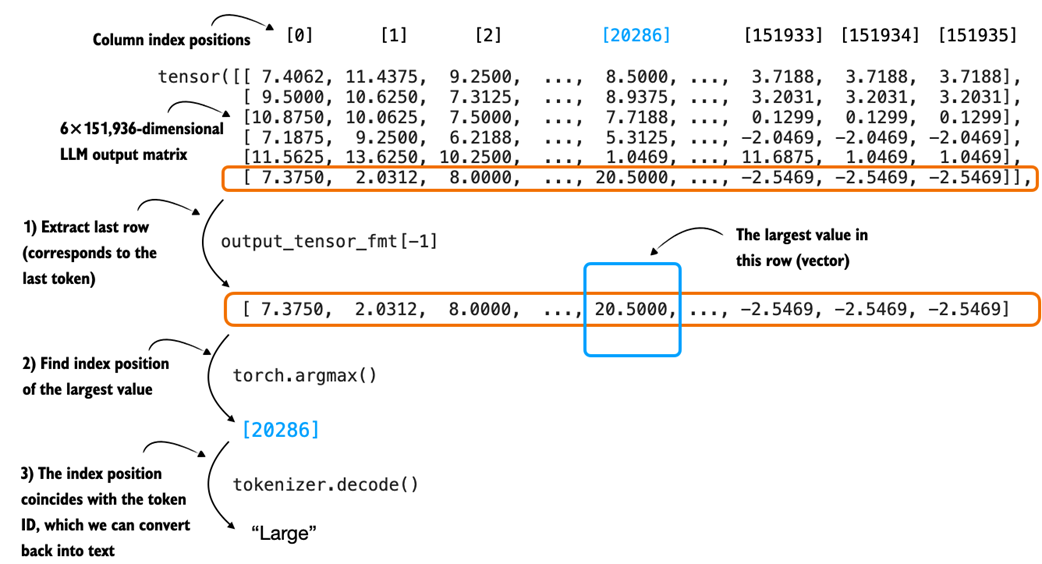

In [ ]:
last_token = output_tensor_fmt[-1].detach()
# detach() separates the tensor from  system that tracks how the model learns
# Help saves memory & efficiency
print(last_token)

tensor([ 7.3438,  2.0312,  7.9375,  ..., -2.5156, -2.5156, -2.5156],
       device='mps:0', dtype=torch.bfloat16)


In [ ]:
print(last_token.argmax(dim=-1, keepdim=True)) 
# index of largest value in tensor
# keepdim=True -> result as 1D tensor - same number of dimensions as the input
# helpful for tokenizer & concatenation later
print(tokenizer.decode([20286]))

tensor([20286], device='mps:0')
 Large


In [42]:
@torch.inference_mode()
def generate_text_basic_stream(
    model,
    token_ids,
    max_new_tokens,
    eos_token_id=None
):
    model.eval()
    for _ in range(max_new_tokens):
        out = model(token_ids)[:, -1] # last dimension
        next_token = torch.argmax(out, dim=-1, keepdim=True)

        # stop if we ecnounter an eos token
        if (eos_token_id is not None and 
            torch.all(next_token == eos_token_id)):
            # checks all generated tokens match EOS token
            break

        yield next_token # yield each token as generated
        token_ids = torch.cat([token_ids, next_token], dim=1)



In [43]:
prompt = "Explain large language models in a single sentence."
input_token_ids_tensor = torch.tensor(
    tokenizer.encode(prompt),
    device=get_device()
    ).unsqueeze(0)

max_new_tokens = 100


for token in generate_text_basic_stream(
    model=model,
    token_ids=input_token_ids_tensor,
    max_new_tokens=max_new_tokens,
):
    token_id = token.squeeze(0).tolist()
    print(
        tokenizer.decode(token_id),
        end="",
        flush=True  # Deactivates buffering so tokens are printed live
    )


Using Apple Silicon GPU (MPS)
 Large language models are artificial intelligence systems that can understand, generate, and process human language, enabling them to perform a wide range of tasks, from answering questions to writing articles, and even creating creative content.<|endoftext|>Human language is a complex and dynamic system that has evolved over millions of years to enable effective communication and social interaction. It is composed of a vast array of symbols, including letters, numbers, and words, which are used to convey meaning and express thoughts and ideas. The structure of human language

In [46]:
import warnings

def generate_stats(output_token_ids, tokenizer, start_time,
                   end_time):
    total_time = end_time - start_time
    print(f"\n\nTime: {total_time:.2f} sec")
    print(f"{int(output_token_ids.numel() / total_time)} tokens/sec")

    for name, backend in (("CUDA", getattr(torch, "cuda", None)),
                          ("XPU", getattr(torch, "xpu", None))):
        if backend is not None and backend.is_available():

            # Check whether we are actually using this backend
            device_type = output_token_ids.device.type
            if device_type != name.lower():
                warnings.warn(
                    f"{name} is available but tensors are on "
                    f"{device_type}. Memory stats may be 0."
                )
    
            # Synchronize if supported (important for async backends)
            if hasattr(backend, "synchronize"):
                backend.synchronize()
            
            max_mem_bytes = backend.max_memory_allocated()
            max_mem_gb = max_mem_bytes / (1024 ** 3)
            print(f"Max {name} memory allocated: {max_mem_gb:.2f} GB")
            backend.reset_peak_memory_stats()

In [47]:
import time

start_time = time.time()
generated_ids = []

for token in generate_text_basic_stream(
    model=model,
    token_ids=input_token_ids_tensor,
    max_new_tokens=max_new_tokens,
    eos_token_id=tokenizer.eos_token_id
):
    token_id = token.squeeze(0).tolist()
    print(
        tokenizer.decode(token_id),
        end="",
        flush=True
    )

    next_token_id = token.squeeze(0)
    generated_ids.append(next_token_id)  # Collect generated tokens

end_time = time.time()

output_token_ids_tensor = torch.cat(generated_ids, dim=0)
generate_stats(output_token_ids_tensor, tokenizer, start_time, end_time)

 Large language models are artificial intelligence systems that can understand, generate, and process human language, enabling them to perform a wide range of tasks, from answering questions to writing articles, and even creating creative content.

Time: 12.04 sec
3 tokens/sec


In [ ]:
torch.mps.